# What drives the price of a car?

![](https://github.com/vegalopm/ml-assignment-mod11/blob/main/images/kurt.jpeg?raw=1)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary.

**Answer:** Build a Lasso model to predict the price of a used car with an MAE under $2K and identify the key features that drive the price of the car by extracting the top ranked non-zero coefficients.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

**Answer:** The steps I will take to understand the data are the following:
1. Call `.info` on the DataFrame to see the column names and data types.
1. Call `.head()` on the DataFrame to see examples of the data in each column.
1. Identify any missing data or issues with the dataset provided that would require cleaning duraing the Data Preparation step.
1. Form hypothesis based on the first exploration of the data.
1. Plot some of the numeric features to observe their distribution.

In [151]:
# Defining all the imports in this cell
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,root_mean_squared_error
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import seaborn as sns
import math

In [152]:
cars = pd.read_csv('data/vehicles.csv')
cars.info()
cars.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [153]:
# Find the possible values for certain columns
for col_name in ['state', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'year']:
    distinct_values = cars[col_name].unique()
    print(col_name, 'possible values: ', distinct_values)

state possible values:  ['az' 'ar' 'fl' 'ma' 'nc' 'ny' 'or' 'pa' 'tx' 'wa' 'wi' 'al' 'ak' 'ca'
 'co' 'ct' 'dc' 'de' 'ga' 'hi' 'id' 'il' 'in' 'ia' 'ks' 'ky' 'la' 'me'
 'md' 'mi' 'mn' 'ms' 'mo' 'mt' 'ne' 'nv' 'nj' 'nm' 'nh' 'nd' 'oh' 'ok'
 'ri' 'sc' 'sd' 'tn' 'ut' 'vt' 'va' 'wv' 'wy']
condition possible values:  [nan 'good' 'excellent' 'fair' 'like new' 'new' 'salvage']
cylinders possible values:  [nan '8 cylinders' '6 cylinders' '4 cylinders' '5 cylinders' 'other'
 '3 cylinders' '10 cylinders' '12 cylinders']
fuel possible values:  [nan 'gas' 'other' 'diesel' 'hybrid' 'electric']
title_status possible values:  [nan 'clean' 'rebuilt' 'lien' 'salvage' 'missing' 'parts only']
transmission possible values:  [nan 'other' 'automatic' 'manual']
drive possible values:  [nan 'rwd' '4wd' 'fwd']
size possible values:  [nan 'full-size' 'mid-size' 'compact' 'sub-compact']
type possible values:  [nan 'pickup' 'truck' 'other' 'coupe' 'SUV' 'hatchback' 'mini-van' 'sedan'
 'offroad' 'bus' 'van' 'convert

### 1. Analyzing the price distribution

In the next few cells I will be analyzing the distribution of car prices in the dataset.

In [154]:
# Output statistics on the price column
cars['price'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,price
count,4.268800e+05
mean,7.519903e+04
std,1.218228e+07
min,0.000000e+00
10%,5.000000e+02
25%,5.900000e+03
50%,1.395000e+04
75%,2.648575e+04
90%,3.759000e+04
95%,4.450000e+04


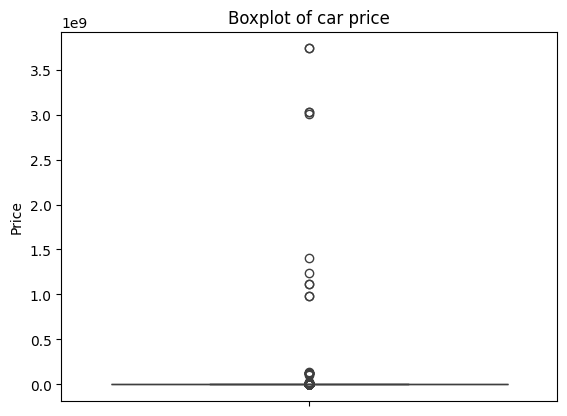

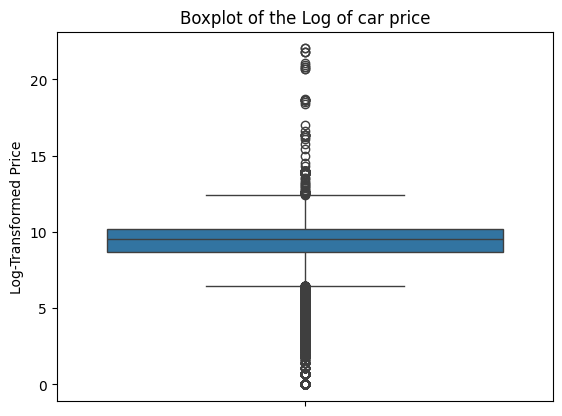

In [155]:
# Graph a box plot of the price column
sns.boxplot(y=cars['price'])
plt.title("Boxplot of car price")
plt.ylabel("Price")
plt.show()
sns.boxplot(y=np.log1p(cars['price']))
plt.ylabel("Log-Transformed Price")
plt.title("Boxplot of the Log of car price")
plt.show()

**Conclusion:** The price data is very skewed. Some data cleaning will be required.

### 2. Analyzing year column

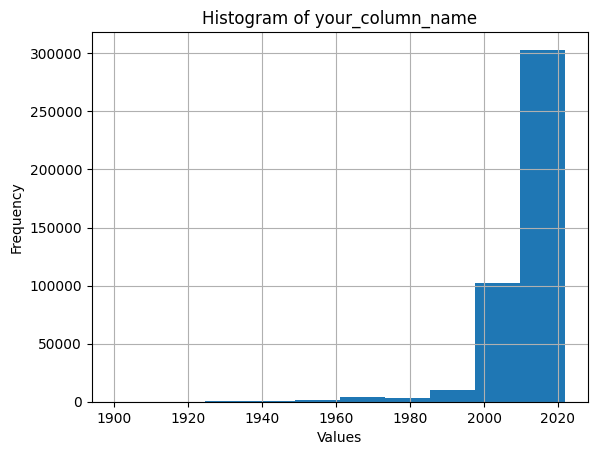

In [156]:
# A histogram of the number of cars per year
cars['year'].hist()
plt.title("Histogram of your_column_name")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

**Conclusion:** The year is very skewed to the right. Some data cleanup might be needed.

### 3. Analyzing ordometer distribution

In [157]:
cars['odometer'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,odometer
count,4.224800e+05
mean,9.804333e+04
std,2.138815e+05
min,0.000000e+00
10%,1.493900e+04
25%,3.770400e+04
50%,8.554800e+04
75%,1.335425e+05
90%,1.773771e+05
95%,2.040000e+05


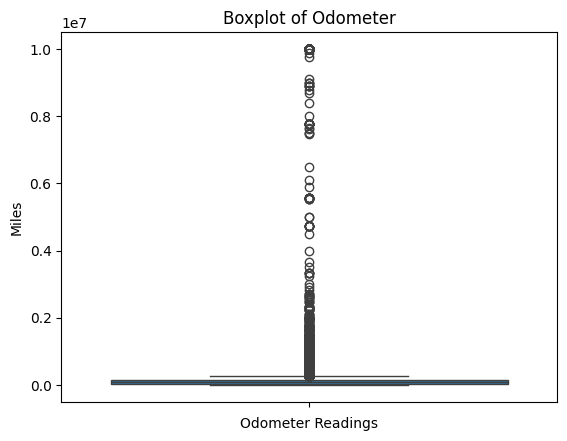

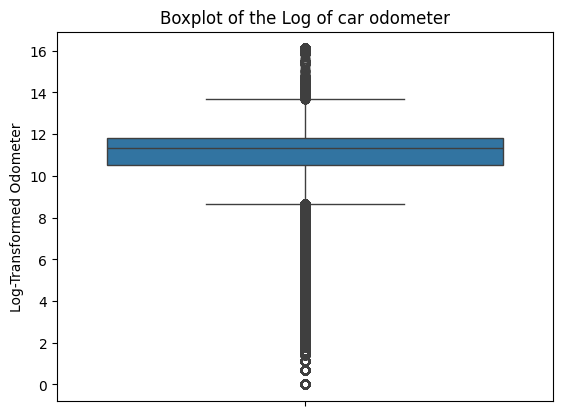

In [158]:
# A boxplot of odometer readings
sns.boxplot(y=cars['odometer'])
plt.title("Boxplot of Odometer")
plt.xlabel("Odometer Readings")
plt.ylabel("Miles")
plt.show()
sns.boxplot(y=np.log1p(cars['odometer']))
plt.ylabel("Log-Transformed Odometer")
plt.title("Boxplot of the Log of car odometer")
plt.show()

**Conclusion:** The odometer data is very skewed too. Some data cleaning is needed.

### Findings From Data Understanding

After analyzing the data, here are some conclusions I made:
1. I will drop `id` and `VIN` because these are just numbers to identify the vehicle that do not provide any significance to the price of the car.
1. I will drop `region` since it is too specific and it is somewhat redundant if `state` is present. **Update:** I ended up droping state too to reduce the number of features.
1. I will drop `model` since there are too many possible values for it and in reality a `model` is used by manufacturers to name a vehicle with a certain set of features such as `cylinders`, `fuel`, `drive`, among others. So, `model` becomes redundant.
1. When `year` is missing, I will fill it with the median `year`. **Update:** After creating a first iteration of the model, I decided I will use `year` to derive a new column `car_age` that is more representative of the value of a car and can be used to derived another important feature: `miles_per_year`.
1. I will fill null values of `odometer` with the median. **Update:** After creating a first iteration of the model, I decided I will use the log since it might be a better representation for the depreciation of the car. Also I will use `odometer` to derive the feature `miles_per_year` that also provides important information about the car.
1. I will not drop rows that contain at least one `Nan` column since there are columns (such as `cylinders`) that have a large number of `NaN` rows and keeping these rows would help more to also evaludate the importance of having a value in these features.
1. I will do 'one-hot' encoding of nonnumeric features.
1. **Update:** After doing a first model, the size feature was essentially zeroed by the model, so I'll be droping it.

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`.

### 1. Drop some columns and cleanup `odometer` and `year`

In [159]:
# Let's first drop the columns I don't need for the reasons mentioned above.
cars.drop(columns=['id', 'VIN', 'region', 'model', 'paint_color', 'size'], inplace=True)

# Now let's fill year with the median and set the year_missing column when the
# value was missing
cars.loc[cars['year'].isna(), 'year'] = cars['year'].median()

# Now let's add the new column car_age. 2023 is used since the most recent car is from 2022.
cars['car_age'] = 2023 - cars['year']

# Now let's fill null values of odometer and add the new column log_odometer
cars.loc[cars['odometer'].isna(), 'odometer'] = cars['odometer'].median()
cars['log_odometer'] = np.log1p(cars['odometer'])

# Now let's calculate the log_miles_per_year column
cars['log_miles_per_year'] = np.log1p(cars['odometer'] / cars['car_age'])

# Let's drop the columns year and odometer now that they are not needed
cars.drop(columns=['year', 'odometer'], inplace=True)

# Let's keep cars whose title is 'clean' or 'rebuilt' and then remove the column as it is not sigificant for driving the price of the car.
cars = cars.loc[(cars['title_status'] == 'clean') | (cars['title_status'] == 'rebuilt')]

cars.info()
cars.head()

<class 'pandas.core.frame.DataFrame'>
Index: 412336 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price               412336 non-null  int64  
 1   manufacturer        395638 non-null  object 
 2   condition           242843 non-null  object 
 3   cylinders           238196 non-null  object 
 4   fuel                410547 non-null  object 
 5   title_status        412336 non-null  object 
 6   transmission        410464 non-null  object 
 7   drive               288047 non-null  object 
 8   type                322812 non-null  object 
 9   state               412336 non-null  object 
 10  car_age             412336 non-null  float64
 11  log_odometer        412336 non-null  float64
 12  log_miles_per_year  412336 non-null  float64
dtypes: float64(3), int64(1), object(9)
memory usage: 44.0+ MB


,price,manufacturer,condition,cylinders,fuel,title_status,transmission,drive,type,state,car_age,log_odometer,log_miles_per_year
27,33590,gmc,good,8 cylinders,gas,clean,other,NaN,pickup,al,9.0,10.966887,8.769801
28,22590,chevrolet,good,8 cylinders,gas,clean,other,NaN,pickup,al,13.0,11.173669,8.608888
29,39590,chevrolet,good,8 cylinders,gas,clean,other,NaN,pickup,al,3.0,9.860632,8.762124
30,30990,toyota,good,8 cylinders,gas,clean,other,NaN,pickup,al,6.0,10.624371,8.832734
31,15000,ford,excellent,6 cylinders,gas,clean,automatic,rwd,truck,al,10.0,11.759793,9.457279


### 2. Remove `price` outliers

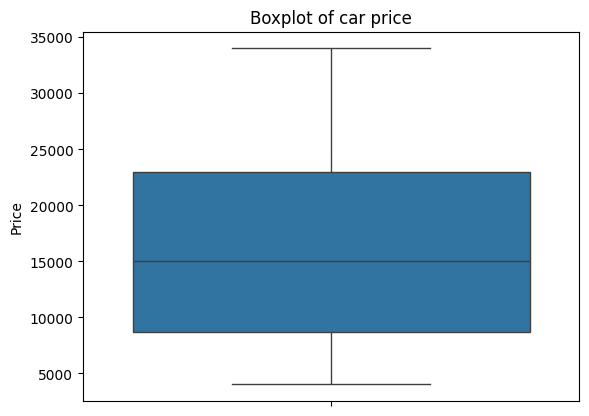

In [160]:
# Keeping higher than 4,000 and lower than 34,000
cars = cars.loc[(cars['price'] > 4_000) & (cars['price'] < 34_000)]
# Graph a box plot of the price column to see the new distribution
sns.boxplot(y=cars['price'])
plt.title("Boxplot of car price")
plt.ylabel("Price")
plt.show()

In [161]:
cars['price'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

,price
count,278397.000000
mean,16284.551741
std,8551.897325
min,4027.000000
10%,5995.000000
25%,8700.000000
50%,14995.000000
75%,22995.000000
90%,29500.000000
95%,31590.000000


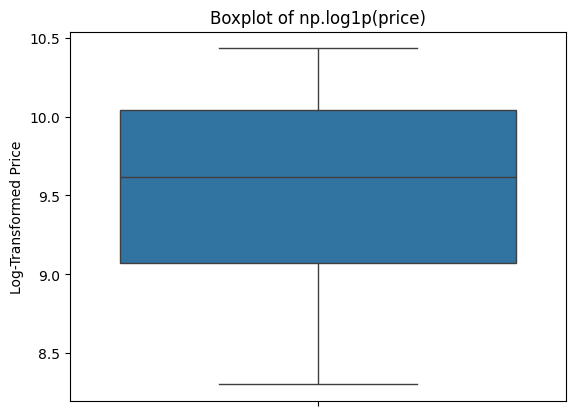

In [162]:
sns.boxplot(y=np.log1p(cars['price']))
plt.title("Boxplot of np.log1p(price)")
plt.ylabel("Log-Transformed Price")
plt.show()

The price distribution looks much better. The log still shows some outliers, so it's something to consider to come back if the model needs improvements.

### 3. Remove `odometer` outliers

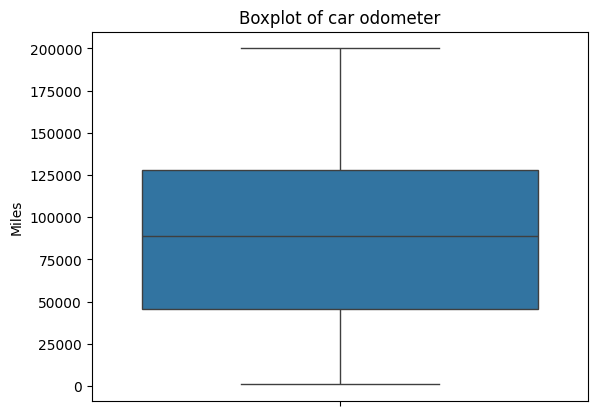

In [163]:
# Let's keep values in the odometer between 1,000 and 200,000 miles
cars = cars.loc[(cars['log_odometer'] > np.log1p(1_000)) & (cars['log_odometer'] < np.log1p(200_000))]
# Graph a box plot of the price column to see the new distribution
sns.boxplot(y=np.expm1(cars['log_odometer']))
plt.title("Boxplot of car odometer")
plt.ylabel("Miles")
plt.show()

### 4. Remove `year` outliers

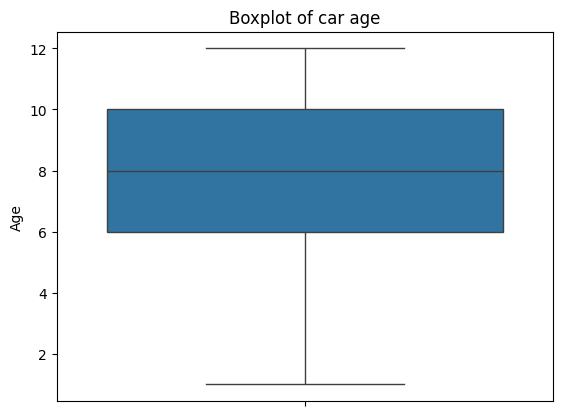

<class 'pandas.core.frame.DataFrame'>
Index: 180657 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   price               180657 non-null  int64  
 1   manufacturer        176731 non-null  object 
 2   condition           111393 non-null  object 
 3   cylinders           97827 non-null   object 
 4   fuel                179551 non-null  object 
 5   title_status        180657 non-null  object 
 6   transmission        179883 non-null  object 
 7   drive               126966 non-null  object 
 8   type                151225 non-null  object 
 9   state               180657 non-null  object 
 10  car_age             180657 non-null  float64
 11  log_odometer        180657 non-null  float64
 12  log_miles_per_year  180657 non-null  float64
dtypes: float64(3), int64(1), object(9)
memory usage: 19.3+ MB


In [164]:
# Let's keep cars from year 1990 and above
cars = cars.loc[cars['car_age'] <= 12]
# Graph a box plot of the price column to see the new distribution
sns.boxplot(y=cars['car_age'])
plt.title("Boxplot of car age")
plt.ylabel("Age")
plt.show()

cars.info()

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [165]:
cars_y = cars['price']
cars_X = cars.drop(columns=['price'])
cars_X_train, cars_X_test, cars_y_train, cars_y_test = train_test_split(cars_X, cars_y, test_size=0.3, random_state=42)

In [166]:
# Have separate pipelines for numeric features and nonnumeric features
numeric_features = ['car_age', 'log_odometer', 'log_miles_per_year']
nonnumeric_features = ['manufacturer', 'condition', 'cylinders', 'fuel', 'transmission', 'drive', 'type', 'title_status', 'state']

# Build numeric features pipeline
cars_numeric_pipe = Pipeline([
    ('polyfeatures', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Build nonnumeric features pipeline
cars_nonnumeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(drop='if_binary', min_frequency=0.01,handle_unknown='infrequent_if_exist'))
])

preprocessor = ColumnTransformer([
    ('numeric', cars_numeric_pipe, numeric_features),
    ('nonnumeric', cars_nonnumeric_pipe, nonnumeric_features)
])

cars_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=5, max_iter=20000, tol=1e-3, eps=1e-2, random_state=42, selection='random'))
])

cars_y_train_log = np.log1p(cars_y_train)
cars_pipe.fit(cars_X_train, cars_y_train_log)

train_preds_log = cars_pipe.predict(cars_X_train)
test_preds_log = cars_pipe.predict(cars_X_test)
lasso_train_rmse = root_mean_squared_error(cars_y_train, np.expm1(train_preds_log))
lasso_test_rmse = root_mean_squared_error(cars_y_test, np.expm1(test_preds_log))
test_mae = mean_absolute_error(cars_y_test, np.expm1(test_preds_log))
test_mape = mean_absolute_percentage_error(cars_y_test, np.expm1(test_preds_log))

print("Train RMSE:  $", f"{lasso_train_rmse:,.2f}")
print("Test RMSE:  $", f"{lasso_test_rmse:,.2f}")
print("Updated Test MAE:   $", f"{test_mae:,.2f}")
print("Updated Test MAPE:  ", f"{test_mape:.2%}")

Train RMSE:  $ 5,049.08
Test RMSE:  $ 5,062.48
Updated Test MAE:   $ 3,845.54
Updated Test MAPE:   22.71%


In [167]:
feature_names = cars_pipe.named_steps['preprocessor'].get_feature_names_out()
lasso_coefs = cars_pipe.named_steps['lasso'].coef_
lasso_df = pd.DataFrame({
    'feature': feature_names,
    'coef': lasso_coefs
})

lasso_df.loc[lasso_df['coef'] != 0]

,feature,coef
1,numeric__log_odometer,0.067177
3,numeric__car_age^2,-0.053665
5,numeric__car_age log_miles_per_year,-0.227570
8,numeric__log_miles_per_year^2,-0.110677
10,nonnumeric__manufacturer_audi,0.075161
11,nonnumeric__manufacturer_bmw,0.077061
14,nonnumeric__manufacturer_chevrolet,-0.045288
16,nonnumeric__manufacturer_dodge,-0.046200
17,nonnumeric__manufacturer_ford,-0.002503
20,nonnumeric__manufacturer_hyundai,-0.085341


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.